In [3]:
# test_dataloader.py
from dataloader import read_file
import numpy as np

# Prova con un file
x_particles, x_jet, y = read_file(
    "data/JetClass/Pythia/train_100M/HToBB_000.root",
    max_num_particles=128
)

print(f"x_particles shape: {x_particles.shape}")  # [num_jets, num_particle_features, max_particles]
print(f"x_jet shape: {x_jet.shape}")              # [num_jets, num_jet_features]
print(f"y shape: {y.shape}")                       # [num_jets, num_labels]

# Verifica i contenuti
print(f"Prime 3 etichette: {y[:3]}")
print(f"Feature particelle del primo jet (prime 5 particelle):\n{x_particles[0, :, :5]}")

x_particles shape: (100000, 4, 128)
x_jet shape: (100000, 4)
y shape: (100000, 10)
Prime 3 etichette: [[0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]]
Feature particelle del primo jet (prime 5 particelle):
[[157.40799    149.75066    105.54        94.27046     60.109467  ]
 [ -0.49381405  -0.50184834  -0.5780048   -0.56758213  -0.8607844 ]
 [ -1.0744866   -1.0702786   -1.0748543   -1.0749397   -0.99387735]
 [176.99333    169.00725    123.66623    109.8671      83.78795   ]]


In [ ]:
# train_simple.py
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, random_split
from jetclass_dataset import JetClassDataset
from simple_model import SimpleJetModel, SimpleJetModelWithGlobal
import glob
import numpy as np

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in loader:
        particles = batch['particles'].to(device)
        jets = batch['jets'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        # Scegli il modello che stai usando
        if isinstance(model, SimpleJetModelWithGlobal):
            logits = model(particles, jets, mask)
        else:
            logits = model(particles, mask)
            
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return total_loss/len(loader), correct/total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in loader:
            particles = batch['particles'].to(device)
            jets = batch['jets'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)
            
            if isinstance(model, SimpleJetModelWithGlobal):
                logits = model(particles, jets, mask)
            else:
                logits = model(particles, mask)
                
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    return total_loss/len(loader), correct/total

def main():
    # Configurazione
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Usando device: {device}")
    
    # Trova i file (inizia con pochi file per test)
    data_dir = "data/JetClass/Pythia/train_100M"
    all_files = glob.glob(f"{data_dir}/*.root")
    
    # Seleziona 2-3 file per classe per bilanciare
    selected_files = []
    for pattern in ['HToBB', 'TTBar', 'WToQQ']:
        files = [f for f in all_files if pattern in f][:2]  # 2 file per classe
        selected_files.extend(files)
    
    print(f"File selezionati: {[f.split('/')[-1] for f in selected_files]}")
    
    # Crea dataset (con limitazione per test)
    full_dataset = JetClassDataset(
        file_paths=selected_files,
        max_num_particles=128,
        max_jets_per_file=10000  # Limita a 10k jet per file
    )
    
    # Split train/val
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(
        full_dataset, [train_size, val_size]
    )
    
    # DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=64,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    
    # Crea modello
    # model = SimpleJetModel(
    #     num_particle_features=4,  # part_pt, eta, phi, energy
    #     num_classes=10,
    #     d_model=128,
    #     nhead=4,
    #     num_layers=4,
    #     max_particles=128
    # )
    
    # Modello con feature globali
    model = SimpleJetModelWithGlobal(
        num_particle_features=4,
        num_jet_features=4,  # jet_pt, eta, phi, energy
        num_classes=10,
        d_model=128,
        nhead=4,
        num_layers=4,
        max_particles=128
    ).to(device)
    
    print(f"Modello creato con {sum(p.numel() for p in model.parameters()):,} parametri")
    
    # Optimizer e loss
    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.CrossEntropyLoss()
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=10,              # Numero di epoche per completare il ciclo
        eta_min=1e-5            # Learning rate finale desiderato
    )
    
    # Training loop
    best_val_acc = 0
    for epoch in range(5):
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, criterion, device
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )
        scheduler.step()
        
        print(f"Epoch {epoch}:")
        print(f"  Train loss: {train_loss:.4f}, acc: {train_acc:.4f}")
        print(f"  Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")
        
        # Salva il miglior modello
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pt')
            print(f"  → Nuovo miglior modello salvato!")
    
    print(f"Miglior accuratezza validation: {best_val_acc:.4f}")

if __name__ == "__main__":
    main()

Usando device: cuda
File selezionati: ['HToBB_001.root', 'HToBB_006.root', 'TTBarLep_006.root', 'TTBarLep_002.root', 'WToQQ_007.root', 'WToQQ_004.root']
Caricamento data/JetClass/Pythia/train_100M/HToBB_001.root...
Caricamento data/JetClass/Pythia/train_100M/HToBB_006.root...
Caricamento data/JetClass/Pythia/train_100M/TTBarLep_006.root...
Caricamento data/JetClass/Pythia/train_100M/TTBarLep_002.root...
Caricamento data/JetClass/Pythia/train_100M/WToQQ_007.root...
Caricamento data/JetClass/Pythia/train_100M/WToQQ_004.root...
Totale jet caricati: 60000
Shape particles: (60000, 4, 128)
Shape jets: (60000, 4)
Shape labels: (60000, 10)
Modello creato con 820,298 parametri


KeyboardInterrupt: 

Usando device: cuda
Modello caricato da best_model.pt
Trovato test file: HToBB_005.root
Trovato test file: TTBarLep_000.root
Trovato test file: WToQQ_009.root

Totale file di test: 3
Caricamento data/JetClass/Pythia/train_100M/HToBB_005.root...
Caricamento data/JetClass/Pythia/train_100M/TTBarLep_000.root...
Caricamento data/JetClass/Pythia/train_100M/WToQQ_009.root...
Totale jet caricati: 15000
Shape particles: (15000, 4, 128)
Shape jets: (15000, 4)
Shape labels: (15000, 10)
Dataset di test: 15000 jet
Classi presenti: [1 7 9]

📊 VALUTAZIONE MODELLO


/home/simone/Code-Ubuntu/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


METRICHE GLOBALI
Accuracy:  0.5908
Precision: 0.5969
Recall:    0.5908
F1-score:  0.5860
METRICHE GLOBALI
Accuracy:  0.5908
Precision: 0.5969
Recall:    0.5908
F1-score:  0.5860
Numero di classi rilevato: 3
Usando 3 classi: ['HBB', 'HCC', 'HGG']


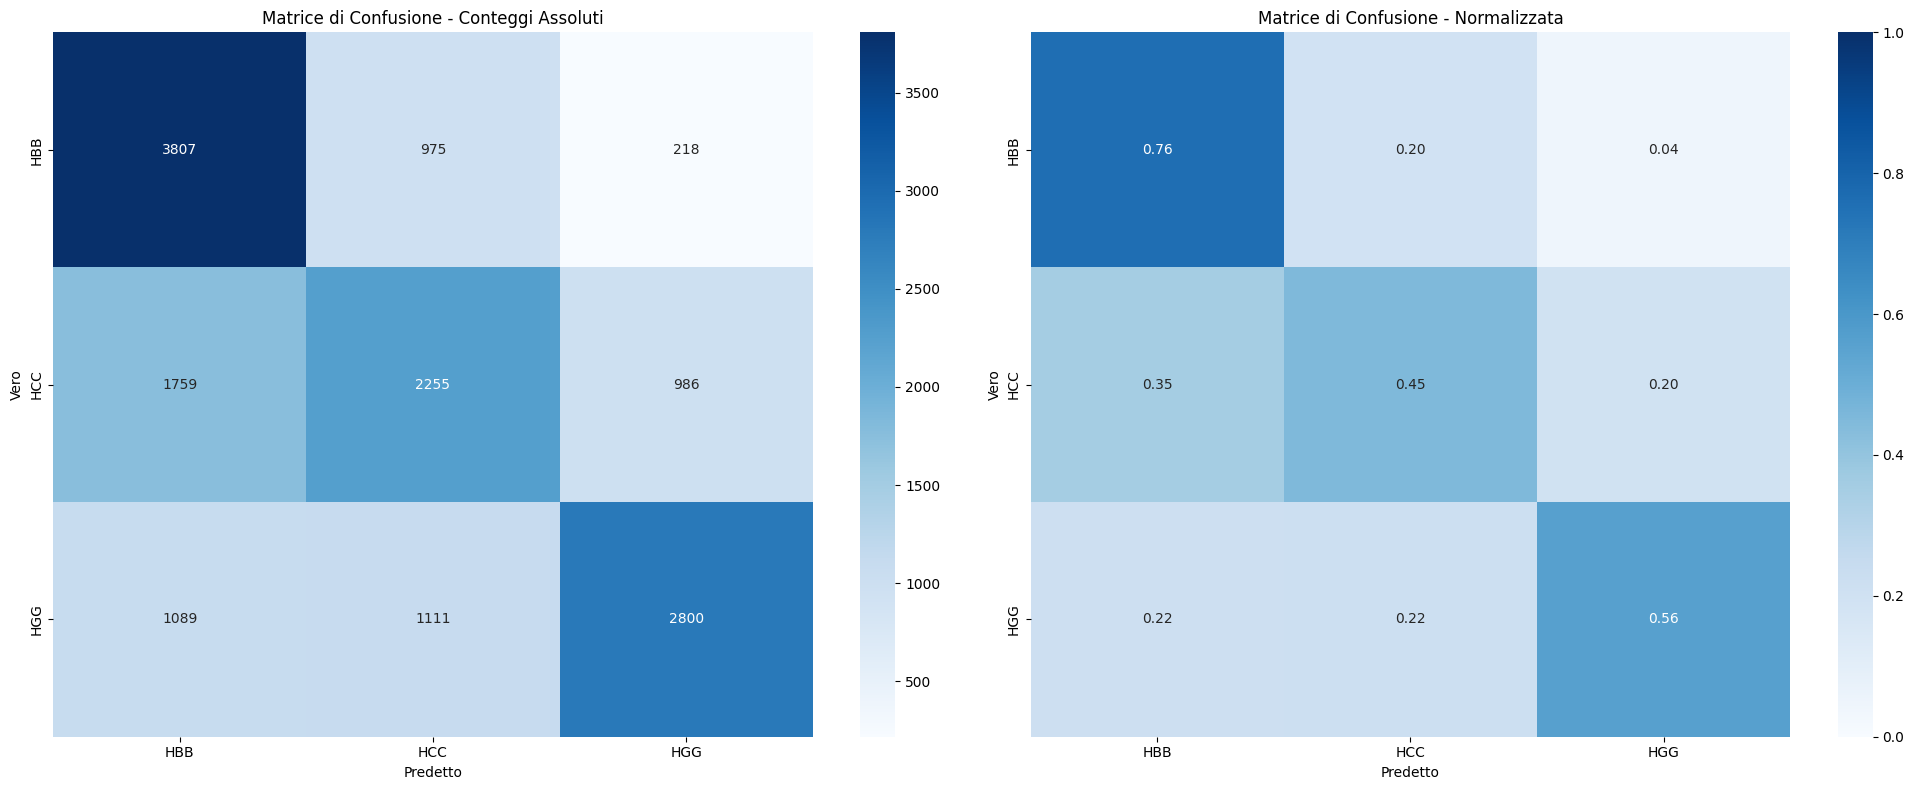


ACCURATEZZA PER CLASSE
HBB: 76.14%
HCC: 45.10%
HGG: 56.00%
METRICHE GLOBALI
Accuracy:  0.5908
Precision: 0.5969
Recall:    0.5908
F1-score:  0.5860


/home/simone/Code-Ubuntu/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/home/simone/Code-Ubuntu/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


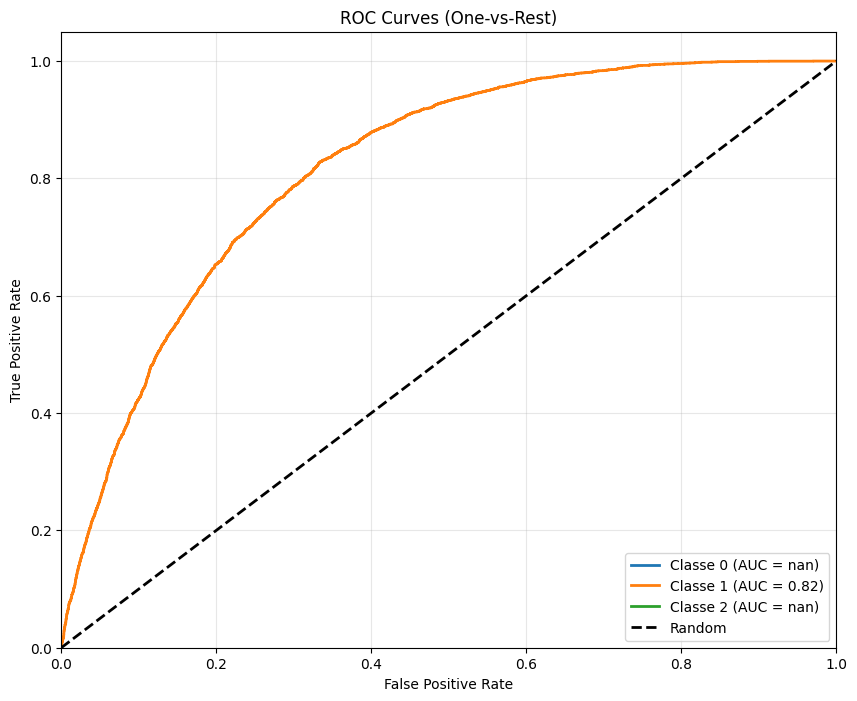

In [1]:
# In una cella Jupyter
from evaluate_in_notebook import evaluate_model_notebook, plot_results_notebook

model, test_loader, device = evaluate_model_notebook(
    model_path='best_model.pt',
    data_dir='data/JetClass/Pythia/train_100M',
    batch_size=64
)

results = plot_results_notebook(model, test_loader, device)

In [2]:
# In una cella Jupyter
from collections import Counter
import numpy as np

# Conta le classi nel test_loader
all_labels = []
for batch in test_loader:
    all_labels.extend(batch['label'].numpy())

unique_labels = np.unique(all_labels)
print(f"Classi presenti: {sorted(unique_labels)}")
print(f"Numero di classi: {len(unique_labels)}")
print(f"Distribuzione: {Counter(all_labels)}")

Classi presenti: [np.int64(1), np.int64(7), np.int64(9)]
Numero di classi: 3
Distribuzione: Counter({np.int64(1): 5000, np.int64(9): 5000, np.int64(7): 5000})


# Mini_Omni

In [1]:
# Cella 1: Import e Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader, random_split
import glob
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Importa il modello
from mini_omnijet import MiniOmniJet#, print_model_summary
from jetclass_dataset import JetClassDataset
from normalized_jetclass_dataset import NormalizedJetClassDataset

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Usando device: {device}")

# Configurazione matplotlib per notebook
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

🚀 Usando device: cuda


In [2]:
# Cella 2: Parametri e DataLoader
data_dir = "data/JetClass/Pythia/train_100M"
batch_size = 32
max_jets_per_file = 10000  # Riduci per test, aumenta dopo

# Trova file (inizia con pochi file)
all_files = glob.glob(f"{data_dir}/*.root")[:2]  # 6 file per iniziare
print(f"File selezionati: {[f.split('/')[-1] for f in all_files]}")

# Crea dataset
full_dataset = JetClassDataset(
    file_paths=all_files,
    max_num_particles=128,
    max_jets_per_file=max_jets_per_file
)

# Applica normalizzazione
norm_dataset = NormalizedJetClassDataset(full_dataset)

# Salva le statistiche per dopo (utile per denormalizzare)
norm_stats = norm_dataset.get_norm_stats()
print(f"Statistiche di normalizzazione salvate")

# Usa norm_dataset invece di full_dataset per il resto
train_size = int(0.8 * len(norm_dataset))
val_size = len(norm_dataset) - train_size
train_dataset, val_dataset = random_split(
    norm_dataset, [train_size, val_size]
)

print(f"Dataset caricato: {len(full_dataset)} jet")
print(f"Shape particles: {full_dataset.particles.shape}")
print(f"Classi presenti: {np.unique(full_dataset.class_indices)}")

# Split train/val
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

File selezionati: ['HToGG_003.root', 'WToQQ_007.root']
Caricamento data/JetClass/Pythia/train_100M/HToGG_003.root...
Caricamento data/JetClass/Pythia/train_100M/WToQQ_007.root...
Totale jet caricati: 20000
Shape particles: (20000, 4, 128)
Shape jets: (20000, 4)
Shape labels: (20000, 10)
Calcolo statistiche (corrette)...
Stats:
pt: mean=1.978, std=0.923
eta: mean=-0.010, std=0.920
sin_phi: mean=0.008, std=0.705
cos_phi: mean=0.000, std=0.709
energy: mean=2.260, std=0.976
Statistiche di normalizzazione salvate
Dataset caricato: 20000 jet
Shape particles: (20000, 4, 128)
Classi presenti: [3 7]
Train batches: 500, Val batches: 125


In [3]:
# Cella 3: Crea Modello
model = MiniOmniJet(
    input_dim=5,
    #latent_dim=16,           # Aumentato da 16
    #vq_hidden_dim=64,       # Aumentato da 64
    num_codes=256,          # Aumentato da 256
    #vq_num_heads=4,          # Aumentato da 2
    #vq_num_blocks=3,         # Aumentato da 2
    #backbone_dim=64,
    #backbone_num_heads=2,
    #backbone_num_layers=4,
    #max_seq_len=128,
    #num_classes=10,
    #dropout=0.1  # <-- AUMENTATO a 0.2 per più regolarizzazione
).to(device)

#print_model_summary(model)

In [4]:
# Cella 4: Funzioni di Training
def train_vqvae(model, train_loader, val_loader, epochs=5, lr=1e-3, device='cuda'):
    """Fase 1: Addestra VQ-VAE"""
    print("\n" + "="*60)
    print("FASE 1: TRAINING VQ-VAE")
    print("="*60)
    
    optimizer = AdamW([
        {'params': model.vqvae.encoder.parameters()},
        {'params': model.vqvae.vq_layer.parameters()},
        {'params': model.vqvae.decoder.parameters()}
    ], lr=lr)
    
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    recon_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_recon = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in pbar:
            particles = batch['particles'].to(device)
            mask = batch['mask'].to(device)
            
            optimizer.zero_grad()
            
            out = model.forward_vqvae(particles, mask)
            recon_loss = F.mse_loss(out['reconstructed'], particles)
            total_loss = recon_loss + out['vq_loss'] + out['commitment_loss']
            
            total_loss.backward()
            optimizer.step()
            
            train_loss += total_loss.item()
            train_recon += recon_loss.item()
            
            pbar.set_postfix({'loss': f"{total_loss.item():.4f}"})
        
        avg_train_loss = train_loss / len(train_loader)
        avg_recon = train_recon / len(train_loader)
        train_losses.append(avg_train_loss)
        recon_losses.append(avg_recon)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                particles = batch['particles'].to(device)
                mask = batch['mask'].to(device)
                
                out = model.forward_vqvae(particles, mask)
                recon_loss = F.mse_loss(out['reconstructed'], particles)
                total_loss = recon_loss + out['vq_loss'] + out['commitment_loss']
                val_loss += total_loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f} (recon={avg_recon:.4f}), val_loss={avg_val_loss:.4f}")
        
        # Salva miglior modello
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_vqvae.pt')
            print(f"  → Miglior modello salvato!")
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(train_losses, label='Train Loss', marker='o')
    ax1.plot(val_losses, label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('VQ-VAE Training Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(recon_losses, label='Reconstruction Loss', marker='o', color='green')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Recon Loss')
    ax2.set_title('Reconstruction Loss')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return model, train_losses, val_losses

def train_generative(model, train_loader, val_loader, epochs=10, lr=1e-4, device='cuda'):
    """Fase 2: Addestra modello generativo"""
    print("\n" + "="*60)
    print("FASE 2: TRAINING GENERATIVO")
    print("="*60)
    
    # Congela VQ-VAE
    for param in model.vqvae.parameters():
        param.requires_grad = False
    
    optimizer = AdamW(model.backbone.parameters(), lr=lr)
    
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in pbar:
            particles = batch['particles'].to(device)
            mask = batch['mask'].to(device)
            
            optimizer.zero_grad()
            
            with torch.no_grad():
                tokens = model.tokenize(particles, mask)
            
            start_token = torch.full(
                (tokens.shape[0], 1), 
                model.num_codes, 
                dtype=torch.long, 
                device=device
            )
            tokens_with_start = torch.cat([start_token, tokens[:, :-1]], dim=1)
            
            _, loss = model.forward_generative(tokens_with_start, mask)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                particles = batch['particles'].to(device)
                mask = batch['mask'].to(device)
                
                tokens = model.tokenize(particles, mask)
                start_token = torch.full(
                    (tokens.shape[0], 1), 
                    model.num_codes, 
                    dtype=torch.long, 
                    device=device
                )
                tokens_with_start = torch.cat([start_token, tokens[:, :-1]], dim=1)
                
                _, loss = model.forward_generative(tokens_with_start, mask)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_generative.pt')
            print(f"  → Miglior modello salvato!")
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Val Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Generative Training Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return model, train_losses, val_losses

def train_classification(model, train_loader, val_loader, epochs=5, lr=1e-4, device='cuda'):
    """Fase 3: Fine-tuning per classificazione"""
    print("\n" + "="*60)
    print("FASE 3: TRAINING CLASSIFICAZIONE")
    print("="*60)
    
    optimizer = AdamW(model.classification_head.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    best_val_acc = 0
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in pbar:
            particles = batch['particles'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)
            
            optimizer.zero_grad()
            
            logits = model.forward_classification(particles, mask)
            loss = criterion(logits, labels)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            preds = logits.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
            
            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{(preds == labels).float().mean().item():.3f}"
            })
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                particles = batch['particles'].to(device)
                mask = batch['mask'].to(device)
                labels = batch['label'].to(device)
                
                logits = model.forward_classification(particles, mask)
                loss = criterion(logits, labels)
                
                val_loss += loss.item()
                preds = logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1}: train_loss={avg_train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"val_loss={avg_val_loss:.4f}, val_acc={val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_classifier.pt')
            print(f"  → Miglior modello salvato!")
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(train_losses, label='Train Loss', marker='o')
    ax1.plot(val_losses, label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Classification Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(train_accs, label='Train Acc', marker='o')
    ax2.plot(val_accs, label='Val Acc', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Classification Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return model, train_losses, val_losses, train_accs, val_accs

In [5]:
# Cella 5: Esegui Fase 1 - VQ-VAE
model, train_losses, val_losses = train_vqvae(
    model, train_loader, val_loader,
    epochs=5*4,  # Aumenta dopo test
    lr=1e-3,
    device=device
)


FASE 1: TRAINING VQ-VAE


Epoch 1/20 [Train]:   0%|          | 0/500 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (4096x4 and 5x64)

In [ ]:
# Cella 6: Esegui Fase 2 - Generativo
# Carica miglior modello VQ-VAE se esiste
if os.path.exists('best_vqvae.pt'):
    model.load_state_dict(torch.load('best_vqvae.pt'))
    print("✅ Caricato miglior modello VQ-VAE")

model, train_losses, val_losses = train_generative(
    model, train_loader, val_loader,
    epochs=5*2,  # Aumenta dopo test
    lr=1e-4,
    device=device
)

✅ Caricato miglior modello VQ-VAE

FASE 2: TRAINING GENERATIVO


Epoch 1/10 [Val]: 100%|██████████| 25/25 [00:00<00:00, 29.27it/s]


Epoch 1: train_loss=5.5288, val_loss=2.9334
  → Miglior modello salvato!


Epoch 2/10 [Train]:  93%|█████████▎| 93/100 [00:05<00:00, 15.92it/s, loss=1.4560]


KeyboardInterrupt: 

✅ Caricato miglior modello generativo

FASE 3: TRAINING CLASSIFICAZIONE


Epoch 1/20 [Val]: 100%|██████████| 13/13 [00:00<00:00, 33.89it/s]


Epoch 1: train_loss=6.8511, train_acc=0.9337, val_loss=0.0000, val_acc=1.0000
  → Miglior modello salvato!


Epoch 2/20 [Val]: 100%|██████████| 13/13 [00:00<00:00, 26.78it/s]


Epoch 2: train_loss=0.0012, train_acc=0.9994, val_loss=0.0000, val_acc=1.0000


...

Epoch 18: train_loss=0.0000, train_acc=1.0000, val_loss=0.0000, val_acc=1.0000


Epoch 19/20 [Val]: 100%|██████████| 13/13 [00:00<00:00, 58.58it/s]


Epoch 19: train_loss=0.0000, train_acc=1.0000, val_loss=0.0000, val_acc=1.0000


Epoch 20/20 [Val]: 100%|██████████| 13/13 [00:00<00:00, 59.06it/s]


Epoch 20: train_loss=0.0000, train_acc=1.0000, val_loss=0.0000, val_acc=1.0000


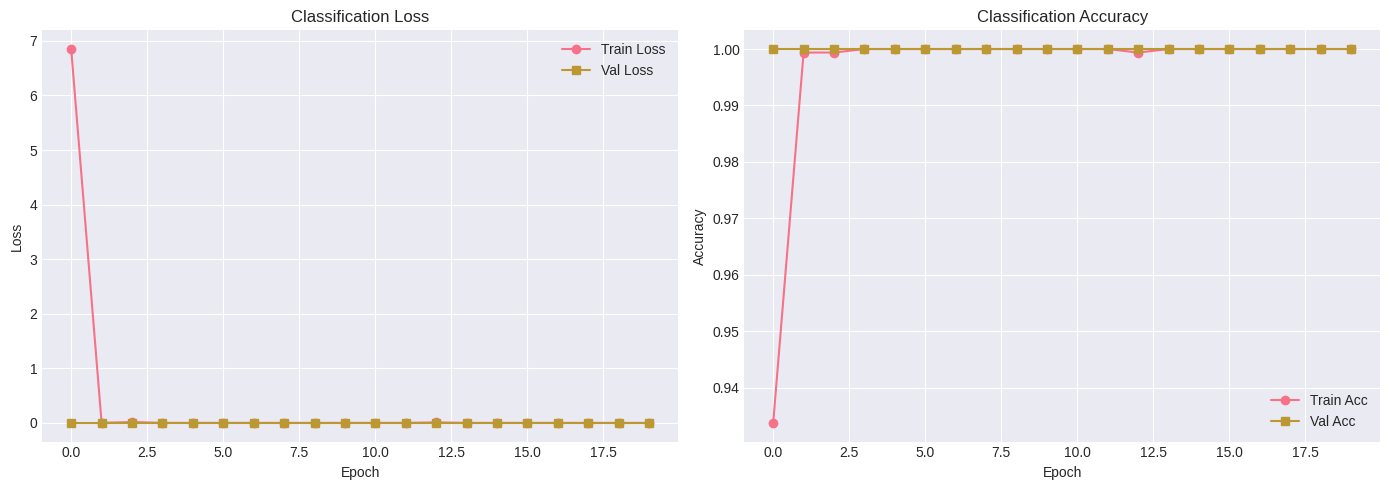

In [ ]:
# Cella 7: Esegui Fase 3 - Classificazione
# Carica miglior modello generativo se esiste
if os.path.exists('best_generative.pt'):
    model.load_state_dict(torch.load('best_generative.pt'))
    print("✅ Caricato miglior modello generativo")

model, train_losses, val_losses, train_accs, val_accs = train_classification(
    model, train_loader, val_loader,
    epochs=5*2,  # Aumenta dopo test
    lr=1e-4,
    device=device
)

In [ ]:
'''
# Cella 8: Test Generazione - VERSIONE CORRETTA
import torch
from mini_omnijet import MiniOmniJet

device = torch.device('cpu')
print(f"🚀 Usando device: {device}")

# 1. Ricrea il modello con gli STESSI parametri usati nel training
model = MiniOmniJet(
    input_dim=4,
    latent_dim=16,
    vq_hidden_dim=64,
    num_codes=256,
    vq_num_heads=2,
    vq_num_blocks=2,
    backbone_dim=64,
    backbone_num_heads=2,
    backbone_num_layers=4,
    max_seq_len=128,
    num_classes=10,
    dropout=0.1
).to(device)

# 2. Carica il checkpoint GENERATIVO (non il VQ-VAE!)
checkpoint_path = 'best_generative.pt'  # o 'best_generative_epochX.pt'

try:
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print(f"✅ Caricato checkpoint: {checkpoint_path}")
except FileNotFoundError:
    print(f"❌ File {checkpoint_path} non trovato!")
    print("Checkpoint disponibili:")
    import os
    for f in os.listdir('.'):
        if f.endswith('.pt'):
            size = os.path.getsize(f) / (1024*1024)
            print(f"  - {f} ({size:.2f} MB)")
    raise

# 3. Metti il modello in modalità valutazione
model.eval()

# 4. Test generazione con gestione errori
print("\n🎯 TEST GENERAZIONE")
print("=" * 60)

try:
    with torch.no_grad():
        # Start token (codice START = num_codes)
        start_token = torch.tensor([[model.num_codes]], dtype=torch.long, device=device)
        print(f"Start token shape: {start_token.shape}, valore: {start_token.item()}")
        
        # Genera passo-passo per debug
        generated = start_token.clone()
        
        for i in range(30):  # genera 30 token
            # Forward pass
            logits = model.forward_generative(generated, return_loss=False)
            
            # Prendi logits dell'ultimo token
            next_logits = logits[:, -1, :] / 0.8  # temperature
            
            # Sampling
            probs = F.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            # Concatena
            generated = torch.cat([generated, next_token], dim=1)
            
            # Mostra progresso ogni 5 step
            if (i + 1) % 5 == 0:
                print(f"Step {i+1}: sequenza lunga {generated.shape[1]}")
        
        print(f"\n✅ Generazione completata!")
        print(f"Sequenza finale shape: {generated.shape}")
        print(f"Token generati (primi 20): {generated[0, :20].cpu().numpy()}")
        
        # Decodifica in particelle
        particles = model.vqvae.decode_tokens(generated)
        print(f"Shape particelle decodificate: {particles.shape}")
        
        # Mostra le prime particelle generate
        particles_np = particles[0, :10].cpu().numpy()
        print("\nPrime 10 particelle generate (pt, eta, phi, energy):")
        for i, p in enumerate(particles_np):
            print(f"  {i+1:2d}: pt={p[0]:6.2f}, eta={p[1]:6.2f}, phi={p[2]:6.2f}, energy={p[3]:6.2f}")
        
except Exception as e:
    print(f"❌ Errore durante la generazione: {e}")
    import traceback
    traceback.print_exc()
'''

'\n# Cella 8: Test Generazione - VERSIONE CORRETTA\nimport torch\nfrom mini_omnijet import MiniOmniJet\n\ndevice = torch.device(\'cpu\')\nprint(f"🚀 Usando device: {device}")\n\n# 1. Ricrea il modello con gli STESSI parametri usati nel training\nmodel = MiniOmniJet(\n    input_dim=4,\n    latent_dim=16,\n    vq_hidden_dim=64,\n    num_codes=256,\n    vq_num_heads=2,\n    vq_num_blocks=2,\n    backbone_dim=64,\n    backbone_num_heads=2,\n    backbone_num_layers=4,\n    max_seq_len=128,\n    num_classes=10,\n    dropout=0.1\n).to(device)\n\n# 2. Carica il checkpoint GENERATIVO (non il VQ-VAE!)\ncheckpoint_path = \'best_generative.pt\'  # o \'best_generative_epochX.pt\'\n\ntry:\n    model.load_state_dict(torch.load(checkpoint_path, map_location=device))\n    print(f"✅ Caricato checkpoint: {checkpoint_path}")\nexcept FileNotFoundError:\n    print(f"❌ File {checkpoint_path} non trovato!")\n    print("Checkpoint disponibili:")\n    import os\n    for f in os.listdir(\'.\'):\n        if f.ends


🎯 VISUALIZZAZIONE RICOSTRUZIONE


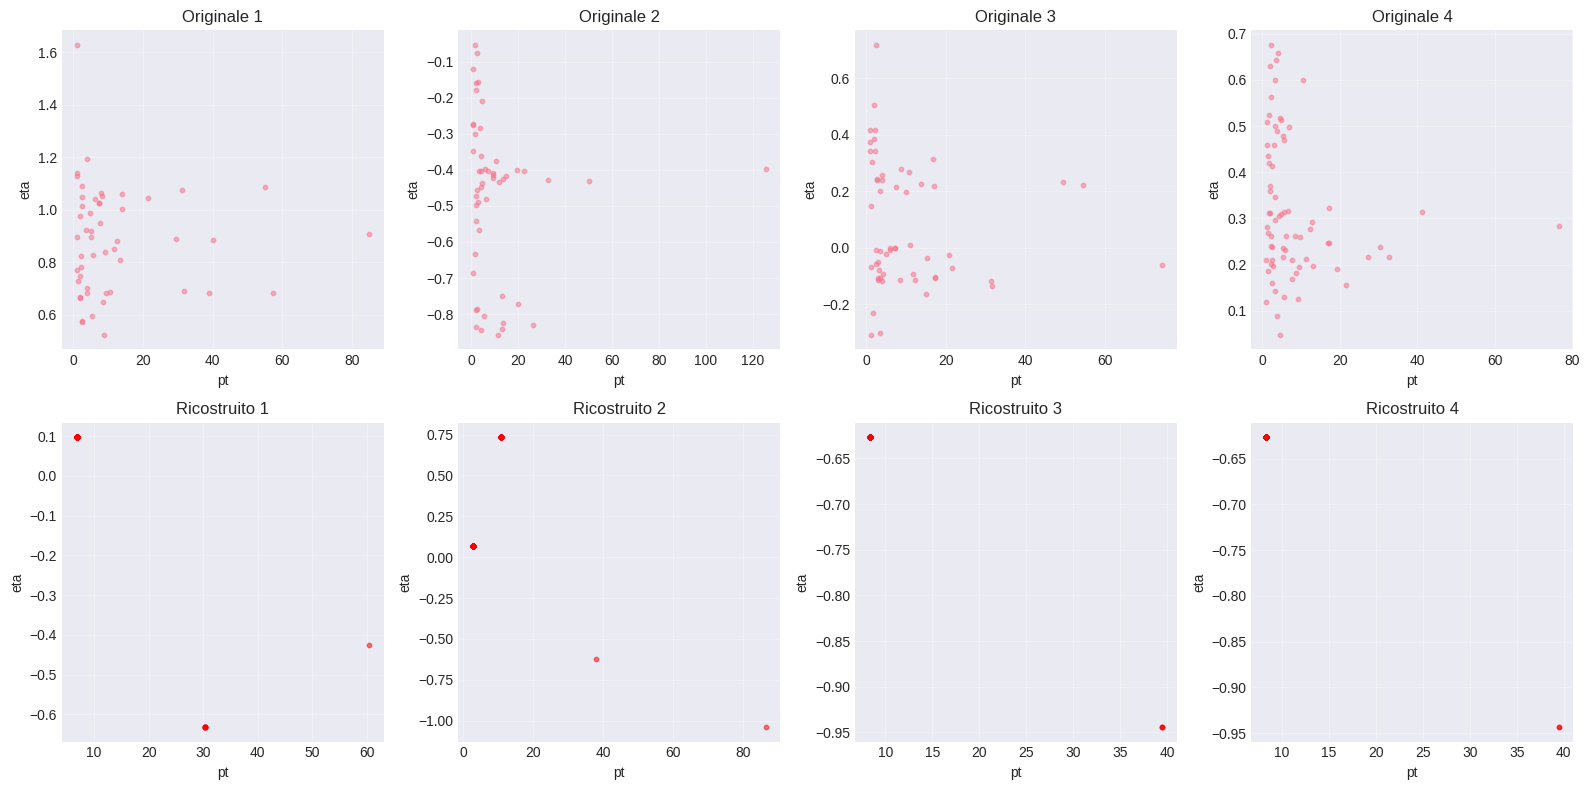

Token del primo jet: [ 246  507  507  507  507  507  507  507 1466 1466 1466 1466 1466 1466
 1466 1466 1466 1466 1466 1466]


In [ ]:
# Cella 9: Visualizza un esempio reale vs ricostruito
print("\n🎯 VISUALIZZAZIONE RICOSTRUZIONE")
print("="*60)

# Prendi un batch
batch = next(iter(val_loader))
particles = batch['particles'][:4].to(device)
mask = batch['mask'][:4].to(device)

with torch.no_grad():
    out = model.forward_vqvae(particles, mask)
    tokens = out['indices']
    reconstructed = out['reconstructed']

# Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    # Originale (pt vs eta)
    orig = particles[i].cpu().numpy()
    mask_np = mask[i].cpu().numpy()
    axes[0, i].scatter(orig[mask_np, 0], orig[mask_np, 1], alpha=0.5, s=10)
    axes[0, i].set_title(f'Originale {i+1}')
    axes[0, i].set_xlabel('pt')
    axes[0, i].set_ylabel('eta')
    axes[0, i].grid(True, alpha=0.3)
    
    # Ricostruito
    reco = reconstructed[i].cpu().numpy()
    axes[1, i].scatter(reco[mask_np, 0], reco[mask_np, 1], alpha=0.5, s=10, color='red')
    axes[1, i].set_title(f'Ricostruito {i+1}')
    axes[1, i].set_xlabel('pt')
    axes[1, i].set_ylabel('eta')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Token del primo jet: {tokens[0, :20].cpu().numpy()}")